# Week 2: Grouping

In [2]:
import numpy as np
import pandas as pd

# Load penguins data
URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = pd.read_csv(URL)

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## Summary Statistics

`sum()`: sum values in each column,
`count()`: count non-NA values in each column,
`size()`: count the number of values in a column (including NA values),
`min()` and `max()`: get the minimum and maximum value in each column,
`mean()` and `median()`: get the mean and median value in each column,
`std()` and `var()`: get the standard deviation and variance in each column.

In [3]:
# Get the number of non-NA values in each column 
penguins.count()

species              344
island               344
bill_length_mm       342
bill_depth_mm        342
flipper_length_mm    342
body_mass_g          342
sex                  333
year                 344
dtype: int64

In [6]:
# Print min value per numerical column
penguins.select_dtypes('number').min()

bill_length_mm         32.1
bill_depth_mm          13.1
flipper_length_mm     172.0
body_mass_g          2700.0
year                 2007.0
dtype: float64

## Grouping

**Split-Apply-Combine** strategy:
- *Split*: Split data into groups (i.e. by column)
- *Apply*: Calcuate summary stats per group
- *Combine*: Combine group summary stats to compare across groups

In [7]:
#Syntax: groupby()
# df.groupby(columns_to_group_by).summary_method()

In [8]:
# Calculate ungrouped flipper_length_mm mean
penguins['flipper_length_mm'].mean()

200.91520467836258

In [10]:
# Calculate mean flipper_length_mm by species
penguins.groupby('species')['flipper_length_mm'].mean()

species
Adelie       189.953642
Chinstrap    195.823529
Gentoo       217.186992
Name: flipper_length_mm, dtype: float64

In [11]:
# Same calculation, but additional rename and sort
ave_flipper = (penguins.groupby('species')
                        ['flipper_length_mm']
                        .mean()
                        .rename('mean_flipper_length')
                        .sort_values(ascending=False)
                        )
ave_flipper

species
Gentoo       217.186992
Chinstrap    195.823529
Adelie       189.953642
Name: mean_flipper_length, dtype: float64

In [12]:
# Same code, but grouping by species and island
avg_flipper_species_island = (penguins.groupby(['species','island'])
                                ['flipper_length_mm']
                                .mean()
                                .rename('mean_flipper_length')
                                .sort_values(ascending=False)
                                )
avg_flipper_species_island

species    island   
Gentoo     Biscoe       217.186992
Chinstrap  Dream        195.823529
Adelie     Torgersen    191.196078
           Dream        189.732143
           Biscoe       188.795455
Name: mean_flipper_length, dtype: float64

## Grouping and NA values

In [29]:
# Find number of sex = NA rows
penguins['sex'].size - penguins['sex'].count()
#penguins[penguins['sex'].isna()].shape[0]

11

In [28]:
# By default, groupby() excludes rows with NA for grouping var
penguins.groupby('sex').size()

sex
female    165
male      168
dtype: int64

In [30]:
# To have NAs be separate group use dropna
penguins.groupby('sex',dropna=False).size()

sex
female    165
male      168
NaN        11
dtype: int64

## Check-In

We are interested in knowing the number of penguins surveyed on each island in different years.

1. Run

    `penguins.groupby(['island','year']).count()`

    and

    `penguins.groupby(['island','year']).size()`

2. Discuss the differences between each output. What method would give you the number of penguins surveyed on each island and year combination?
    - The `size()` option is slightly better, since one column (Series) of data is returned, and the NAs in the sex column don't effect the total penguin count.

In [31]:
# Count() version
penguins.groupby(['island','year']).count()

species  bill_length_mm  bill_depth_mm  flipper_length_mm  \
island    year                                                              
Biscoe    2007       44              44             44                 44   
          2008       64              64             64                 64   
          2009       60              59             59                 59   
Dream     2007       46              46             46                 46   
          2008       34              34             34                 34   
          2009       44              44             44                 44   
Torgersen 2007       20              19             19                 19   
          2008       16              16             16                 16   
          2009       16              16             16                 16   

                body_mass_g  sex  
island    year                    
Biscoe    2007           44   43  
          2008           64   63  
          2009           59   57  
Dream     2007           46   45  
          2008           34   34  
          2009           44   44  
Torgersen 2007           19   15  
          2008           16   16  
          2009           16   16

In [33]:
# Size() version
penguins.groupby(['island','year']).size()

island     year
Biscoe     2007    44
           2008    64
           2009    60
Dream      2007    46
           2008    34
           2009    44
Torgersen  2007    20
           2008    16
           2009    16
dtype: int64

<Axes: title={'center': 'Penguins surveyed at the Palmer Archipelago'}, xlabel='Number of penguins', ylabel='Island, Year'>

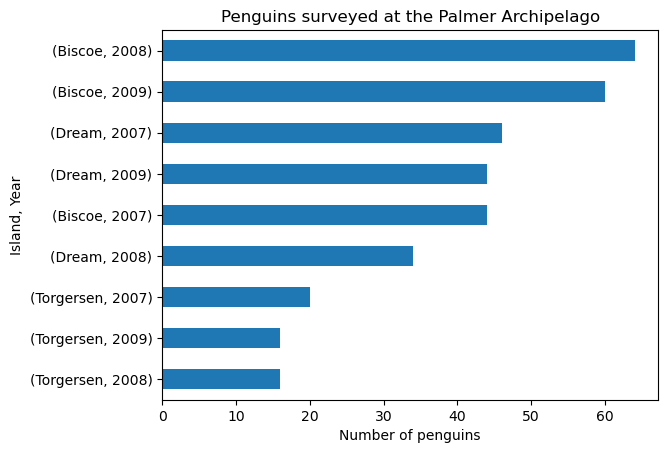

In [34]:
# Plotting the (island, year) number of penguins
(penguins.groupby(['island','year'])
         .size()
         .sort_values()
         .plot(kind='barh',
                title='Penguins surveyed at the Palmer Archipelago',
                xlabel='Number of penguins',
                ylabel='Island, Year')
         )

## Check-In

1. Use the max() method to calculate the maximum value of a penguin’s body mass by year and species.
   
3. Use (1) to display the highest body masses per year and species as a bar plot in descending order.

In [37]:
# Display max body_mass_g per year,species group
penguins.groupby(['year','species'])['body_mass_g'].max()

year  species  
2007  Adelie       4675.0
      Chinstrap    4400.0
      Gentoo       6300.0
2008  Adelie       4700.0
      Chinstrap    4800.0
      Gentoo       6000.0
2009  Adelie       4775.0
      Chinstrap    4450.0
      Gentoo       6000.0
Name: body_mass_g, dtype: float64

<Axes: title={'center': 'Penguin Max Body Mass (g) per Year, Species'}, xlabel='Body Mass (g)', ylabel='Year, Species'>

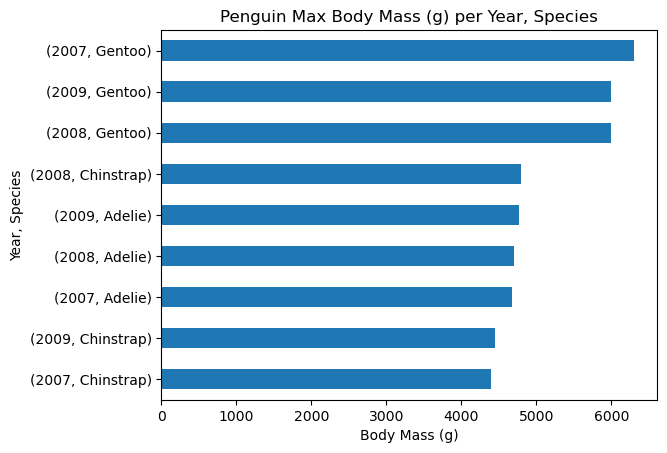

In [40]:
# Create bar plot of above max() data, descending
(penguins.groupby(['year','species'])
                ['body_mass_g']
                .max()
                .sort_values()
                .plot(kind='barh',
                title='Penguin Max Body Mass (g) per Year, Species',
                xlabel='Body Mass (g)',
                ylabel='Year, Species' 
                )
)


## Lesson Summary

Grouping uses `groupby()` to group rows by shared values in one or more columns.

Summary statistic functions provide info on a (grouped) DataFrame:
- `sum()`
- `count()`
- `size()`
- `min()` and `max()`
- `mean()` and `median()`
- `std()` and `var()`
